# 01 · Forecasting — Jena Climate (24h-ahead temperature)

**목표:** 향후 24시간 기온(`T (degC)`)을 예측.

**비교 모델**
1. Naïve — 직전값 반복
2. SARIMA (1주일 데이터로 빠르게)
3. XGBoost — lag/시간 인코딩 feature
4. LSTM — PyTorch GPU

**평가 지표:** MAE, RMSE, MAPE

In [1]:
import sys, time
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src import data_loader, preprocessing, features, models_baseline, models_dl, train, evaluate, visualize

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
DEVICE = train.get_device()
print('Device:', DEVICE)

Device: cuda


## 1. 데이터 로드 & 전처리

10분 → 1시간 다운샘플링. 시간순 70/15/15 분할.

In [2]:
df_full = data_loader.load_jena_climate()
df = preprocessing.downsample_hourly(df_full)
print('shape after hourly resample:', df.shape)
print('range:', df.index.min(), '→', df.index.max())
df.head()

shape after hourly resample: (70129, 14)
range: 2009-01-01 00:00:00 → 2017-01-01 00:00:00


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


In [3]:
TARGET = 'T (degC)'
INPUT_LEN = 120   # 5 days of hourly observations
HORIZON = 24      # predict next 24 hours

train_df, val_df, test_df = preprocessing.time_split(df, ratios=(0.7, 0.15, 0.15))
print('train:', train_df.shape, 'val:', val_df.shape, 'test:', test_df.shape)

train: (49090, 14) val: (10519, 14) test: (10520, 14)


## 2. Naïve baseline

테스트 셋에서 24h-ahead 윈도우마다 직전값 반복.

In [4]:
test_series = test_df[TARGET].values
naive_preds, naive_truth = [], []
for start in range(INPUT_LEN, len(test_series) - HORIZON):
    history = test_series[start - INPUT_LEN : start]
    truth = test_series[start : start + HORIZON]
    naive_preds.append(models_baseline.naive_forecast(history, HORIZON))
    naive_truth.append(truth)
naive_preds = np.array(naive_preds)
naive_truth = np.array(naive_truth)
print('naive_preds shape:', naive_preds.shape)
naive_metrics = evaluate.regression_report(naive_truth, naive_preds)
naive_metrics

naive_preds shape: (10376, 24)


{'MAE': 3.118230513568608,
 'RMSE': 4.2339587035893835,
 'MAPE': 119.52649494793299}

## 3. SARIMA baseline

전체 시계열 SARIMA는 매우 느립니다. 학습 마지막 720시간(=30일)만 사용해 빠르게 적합.

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_train = train_df[TARGET].iloc[-720:]
t0 = time.time()
sarima_model = SARIMAX(sarima_train, order=(2,0,1), seasonal_order=(1,0,1,24), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(f'SARIMA fitted in {time.time()-t0:.1f}s')

# Roll-forward 예측: test 윈도우들 대해 24h step forecast
sarima_preds, sarima_truth = [], []
for start in range(INPUT_LEN, len(test_series) - HORIZON, 48):  # stride 48 to keep runtime small
    history = np.concatenate([sarima_train.values, test_series[:start]])
    res = SARIMAX(history, order=(2,0,1), seasonal_order=(1,0,1,24), enforce_stationarity=False, enforce_invertibility=False).filter(sarima_model.params)
    fc = res.forecast(steps=HORIZON)
    sarima_preds.append(np.asarray(fc))
    sarima_truth.append(test_series[start : start + HORIZON])
sarima_preds = np.array(sarima_preds)
sarima_truth = np.array(sarima_truth)
sarima_metrics = evaluate.regression_report(sarima_truth, sarima_preds)
sarima_metrics

SARIMA fitted in 1.1s


{'MAE': 2.3048365207987147,
 'RMSE': 3.092173730986679,
 'MAPE': 143.75498147077082}

## 4. XGBoost — lag features

타깃은 `T (degC).shift(-24)`. lag 1, 24, 168 + sin/cos 시간 인코딩.

In [6]:
Xtr, ytr = features.make_supervised_table(train_df, target=TARGET, horizon=HORIZON, lags=(1,24,168))
Xva, yva = features.make_supervised_table(val_df, target=TARGET, horizon=HORIZON, lags=(1,24,168))
Xte, yte = features.make_supervised_table(test_df, target=TARGET, horizon=HORIZON, lags=(1,24,168))
print('Xtr:', Xtr.shape, '  Xte:', Xte.shape)

xgb_model = models_baseline.fit_xgb_regressor(Xtr, ytr, n_estimators=400)
xgb_pred = xgb_model.predict(Xte)
xgb_metrics = evaluate.regression_report(yte.values, xgb_pred)
xgb_metrics

Xtr: (48898, 21)   Xte: (10328, 21)


{'MAE': 2.3782079398656744,
 'RMSE': 3.0094080004611574,
 'MAPE': 117.2848017280876}

## 5. LSTM (PyTorch, GPU)

Multi-feature input → multi-step output (24h).

In [7]:
FEATURE_COLS = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)']
TARGET_IDX = 0  # T (degC) is column 0 in FEATURE_COLS

scaler = preprocessing.StandardScaler1D().fit(train_df[FEATURE_COLS].values)
tr_arr = scaler.transform(train_df[FEATURE_COLS].values)
va_arr = scaler.transform(val_df[FEATURE_COLS].values)
te_arr = scaler.transform(test_df[FEATURE_COLS].values)

Xtr_w, ytr_w = preprocessing.make_supervised_windows(tr_arr, INPUT_LEN, HORIZON, target_col=TARGET_IDX, step=1)
Xva_w, yva_w = preprocessing.make_supervised_windows(va_arr, INPUT_LEN, HORIZON, target_col=TARGET_IDX, step=1)
Xte_w, yte_w = preprocessing.make_supervised_windows(te_arr, INPUT_LEN, HORIZON, target_col=TARGET_IDX, step=1)
print('Xtr_w:', Xtr_w.shape, 'Xte_w:', Xte_w.shape)

Xtr_w: (48947, 120, 4) Xte_w: (10377, 120, 4)


In [8]:
BATCH = 256
EPOCHS = 8

tr_loader = train.make_loader(Xtr_w, ytr_w, batch_size=BATCH, shuffle=True)
va_loader = train.make_loader(Xva_w, yva_w, batch_size=BATCH, shuffle=False)
te_loader = train.make_loader(Xte_w, yte_w, batch_size=BATCH, shuffle=False)

lstm = models_dl.LSTMForecaster(n_features=len(FEATURE_COLS), hidden=64, num_layers=2, horizon=HORIZON)
history = train.train_model(
    lstm, tr_loader, va_loader,
    loss_fn=torch.nn.MSELoss(),
    metric_fn=lambda p, y: float(torch.mean(torch.abs(p - y)).item()),
    epochs=EPOCHS, lr=1e-3,
)

epoch 1/8:   0%|          | 0/192 [00:00<?, ?it/s]

epoch  1: train_loss=0.2869  val_loss=0.1256  val_metric=0.2738


epoch 2/8:   0%|          | 0/192 [00:00<?, ?it/s]

epoch  2: train_loss=0.1028  val_loss=0.0995  val_metric=0.2411


epoch 3/8:   0%|          | 0/192 [00:00<?, ?it/s]

...

epoch  6: train_loss=0.0814  val_loss=0.0870  val_metric=0.2213


epoch 7/8:   0%|          | 0/192 [00:00<?, ?it/s]

epoch  7: train_loss=0.0786  val_loss=0.0900  val_metric=0.2256


epoch 8/8:   0%|          | 0/192 [00:00<?, ?it/s]

epoch  8: train_loss=0.0767  val_loss=0.0881  val_metric=0.2230


In [9]:
lstm_pred_scaled = train.predict(lstm, te_loader)
# inverse-scale only the target column
t_mean, t_std = scaler.mean_[TARGET_IDX], scaler.std_[TARGET_IDX]
lstm_pred = lstm_pred_scaled * t_std + t_mean
lstm_truth = yte_w * t_std + t_mean

lstm_metrics = evaluate.regression_report(lstm_truth, lstm_pred)
lstm_metrics

{'MAE': 1.7992261399499834,
 'RMSE': 2.3585874249587975,
 'MAPE': 90.5856242719341}

## 6. 모델 비교 & 시각화

In [10]:
all_metrics = {
    'Naive':   naive_metrics,
    'SARIMA':  sarima_metrics,
    'XGBoost': xgb_metrics,
    'LSTM':    lstm_metrics,
}
metrics_df = pd.DataFrame(all_metrics).T
metrics_df

,MAE,RMSE,MAPE
Naive,3.118231,4.233959,119.526495
SARIMA,2.304837,3.092174,143.754981
XGBoost,2.378208,3.009408,117.284802
LSTM,1.799226,2.358587,90.585624


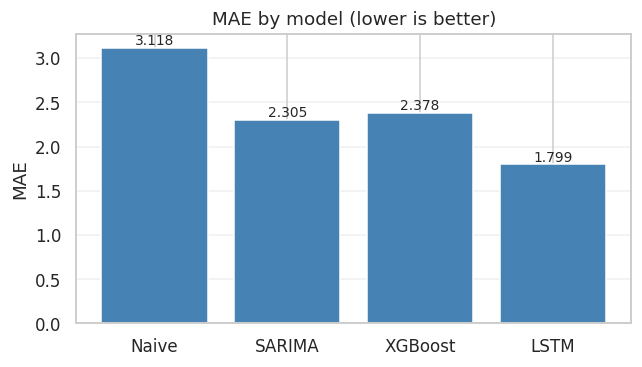

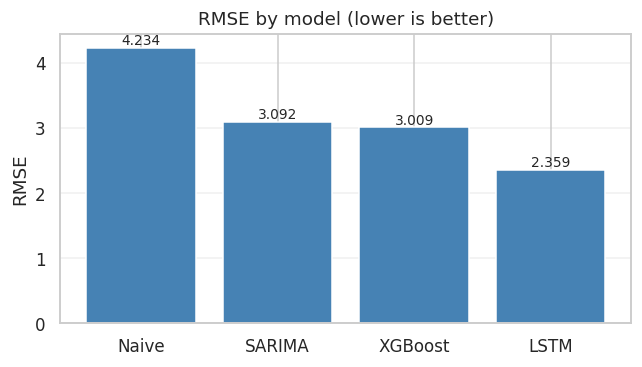

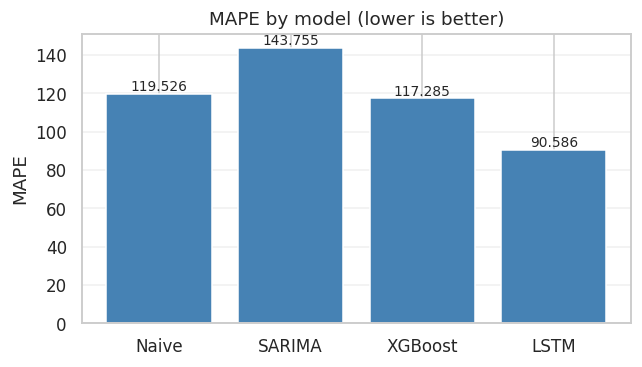

In [11]:
for metric in ('MAE', 'RMSE', 'MAPE'):
    visualize.plot_metric_bars(all_metrics, metric_name=metric, save_as=f'forecast_{metric}.png')
plt.show()

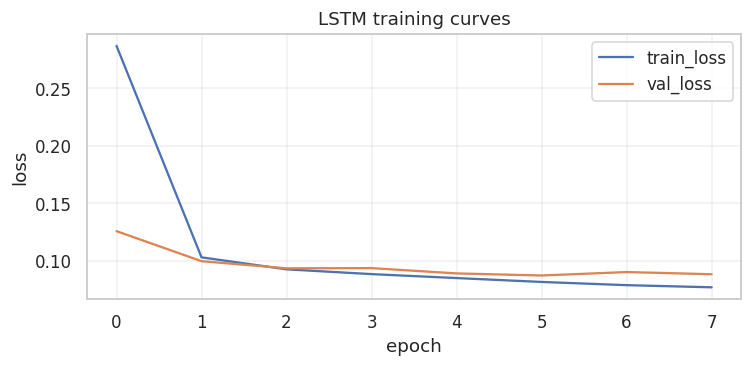

In [12]:
# 학습 곡선
_ = visualize.plot_training_curves(history, title='LSTM training curves', save_as='forecast_lstm_curves.png')
plt.show()

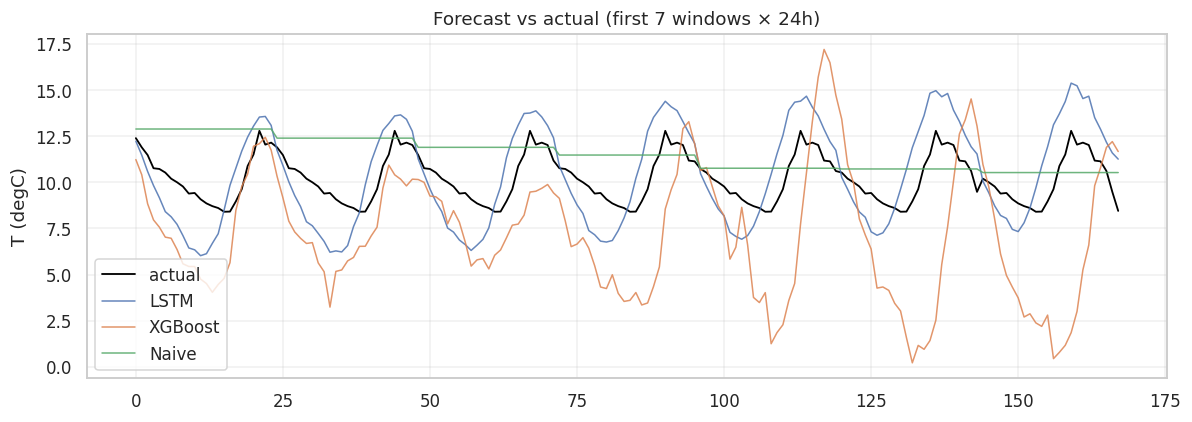

In [13]:
# 예측 vs 실제 (테스트 셋의 처음 한 주 분량 = 168시간 = 7개 forecast 윈도우 평탄화)
n_show = 7
actual_flat = lstm_truth[:n_show].reshape(-1)
lstm_flat   = lstm_pred[:n_show].reshape(-1)
xgb_flat    = xgb_pred[:n_show * HORIZON][: len(actual_flat)]
naive_flat  = naive_preds[:n_show].reshape(-1)[: len(actual_flat)]
ts = np.arange(len(actual_flat))
_ = visualize.plot_forecast_vs_actual(
    ts, actual_flat,
    predictions={'LSTM': lstm_flat, 'XGBoost': xgb_flat, 'Naive': naive_flat},
    title='Forecast vs actual (first 7 windows × 24h)',
    save_as='forecast_vs_actual.png',
)
plt.show()

## 7. 결론

- 일반적으로 LSTM/XGBoost가 Naïve보다 큰 폭으로 우수
- SARIMA는 짧은 학습 셋과 단순한 차수로 인해 절대 성능은 낮을 수 있음 — order/period grid search로 개선 여지
- 결과 PNG는 `reports/figures/forecast_*.png` 에 저장됨